# 1D-CNN 기반 네트워크 침입 탐지 (v2 - Focal Loss)

**변경 사항 (v1 대비)**
- `CrossEntropyLoss` → `Focal Loss` (gamma=2.0)
- 샘플 수 역비례 alpha 가중치 적용 (Infiltration 강화)
- 체크포인트: `checkpoint_v2.pt` / `best_model_v2.pt`

---
### 순서
1. 라이브러리 임포트
2. 데이터 로드 & 분할
3. Dataset / DataLoader 정의
4. 1D-CNN 모델 정의
5. Focal Loss 정의
6. 학습
7. 평가 (Confusion Matrix, Classification Report)
8. 모델 저장

## 1. 라이브러리 임포트

In [3]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 재현성 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

PyTorch version : 2.11.0+cu126
Device          : cuda


## 2. 데이터 로드 & 분할

In [4]:
BASE_DIR   = os.path.dirname(os.path.abspath("__file__"))
OUTPUT_DIR = os.path.join(BASE_DIR, "processed")
MODEL_DIR  = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X = np.load(os.path.join(OUTPUT_DIR, "X.npy"))
y = np.load(os.path.join(OUTPUT_DIR, "y.npy"))

with open(os.path.join(OUTPUT_DIR, "label_mapping.json"), encoding="utf-8") as f:
    label_mapping = json.load(f)

idx2label   = {v: k for k, v in label_mapping.items()}
class_names = [idx2label[i] for i in range(len(idx2label))]
num_classes = len(class_names)

print(f"X shape     : {X.shape}")
print(f"y shape     : {y.shape}")
print(f"클래스 수   : {num_classes}")
print(f"클래스 목록 : {class_names}")

# Train 70 / Val 15 / Test 15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"\nTrain : {X_train.shape[0]:,}")
print(f"Val   : {X_val.shape[0]:,}")
print(f"Test  : {X_test.shape[0]:,}")

X shape     : (2330915, 70)
y shape     : (2330915,)
클래스 수   : 7
클래스 목록 : ['Benign', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Infiltration', 'SQL Injection']

Train : 1,631,640
Val   : 349,637
Test  : 349,638


## 3. Dataset / DataLoader 정의

In [5]:
class IDSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 512

train_loader = DataLoader(IDSDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(IDSDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(IDSDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 3187
Val   batches : 683
Test  batches : 683


## 4. 1D-CNN 모델 정의

In [14]:
class CNN1D(nn.Module):
    def __init__(self, num_features: int, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.conv_blocks(x))


num_features = X_train.shape[1]
model = CNN1D(num_features=num_features, num_classes=num_classes).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"학습 가능 파라미터 수: {total_params:,}")

학습 가능 파라미터 수: 158,215


## 5. Focal Loss 정의

CrossEntropyLoss 대비 개선점:
- **(1 - p_t)^gamma** 항이 쉽게 분류되는 샘플의 기여를 줄임
- **alpha** 가중치로 소수 클래스(Infiltration) 강화
- v1에서 Infiltration Recall 26.3% → 개선 목표

In [15]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss    = nn.functional.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        p_t        = torch.exp(-ce_loss)
        focal_loss = (1 - p_t) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == "mean" else focal_loss.sum()

train_counts = torch.zeros(num_classes)
for i in range(num_classes):
    train_counts[i] = (torch.tensor(y_train) == i).sum()

median_count = train_counts.median()
alpha = torch.sqrt(median_count / train_counts)     # sqrt로 극단적 차이 완화
alpha = (alpha / alpha.sum() * num_classes).to(DEVICE)

print("클래스별 alpha 가중치 (완화):")
for i, (name, a, cnt) in enumerate(zip(class_names, alpha, train_counts)):
    print(f"  {i} {name:<15}: alpha={a:.4f}  (샘플 수: {int(cnt):,})")

criterion = FocalLoss(alpha=alpha, gamma=2.0)
print(f"\nFocal Loss (gamma=2.0, sqrt-alpha) 적용 완료")


클래스별 alpha 가중치 (완화):
  0 Benign         : alpha=0.2366  (샘플 수: 350,000)
  1 Bot            : alpha=0.3128  (샘플 수: 200,333)
  2 Brute Force    : alpha=0.2708  (샘플 수: 267,253)
  3 DDoS           : alpha=0.2366  (샘플 수: 350,000)
  4 DoS            : alpha=0.2366  (샘플 수: 350,000)
  5 Infiltration   : alpha=0.4158  (샘플 수: 113,354)
  6 SQL Injection  : alpha=5.2909  (샘플 수: 700)

Focal Loss (gamma=2.0, sqrt-alpha) 적용 완료


## 6. 학습

In [16]:
EPOCHS   = 50
LR       = 1e-3
PATIENCE = 7

CKPT_PATH = os.path.join(MODEL_DIR, "checkpoint_v2.pt")
BEST_PATH = os.path.join(MODEL_DIR, "best_model_v2.pt")

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
patience_cnt  = 0
start_epoch   = 1

# 체크포인트 복원
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    history       = ckpt["history"]
    best_val_loss = ckpt["best_val_loss"]
    patience_cnt  = ckpt["patience_cnt"]
    start_epoch   = ckpt["epoch"] + 1
    print(f"체크포인트 복원 완료 → epoch {ckpt['epoch']} 이후부터 재시작")
else:
    print("체크포인트 없음 → 처음부터 학습 (Focal Loss v2)")

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total


for epoch in range(start_epoch, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train_loss={tr_loss:.6f}  train_acc={tr_acc:.4f}  "
          f"val_loss={vl_loss:.6f}  val_acc={vl_acc:.4f}")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_cnt  = 0
        torch.save(model.state_dict(), BEST_PATH)
    else:
        patience_cnt += 1

    torch.save({
        "epoch"           : epoch,
        "model_state"     : model.state_dict(),
        "optimizer_state"  : optimizer.state_dict(),
        "scheduler_state" : scheduler.state_dict(),
        "history"         : history,
        "best_val_loss"   : best_val_loss,
        "patience_cnt"    : patience_cnt,
    }, CKPT_PATH)

    if patience_cnt >= PATIENCE:
        print(f"\nEarly Stopping (patience={PATIENCE})")
        break

print("\n학습 완료. Best val_loss:", round(best_val_loss, 6))


체크포인트 없음 → 처음부터 학습 (Focal Loss v2)
Epoch 01/50  train_loss=0.006169  train_acc=0.8001  val_loss=0.021774  val_acc=0.6143
Epoch 02/50  train_loss=0.003729  train_acc=0.8119  val_loss=0.003736  val_acc=0.8162
Epoch 03/50  train_loss=0.003245  train_acc=0.8130  val_loss=0.003077  val_acc=0.8200
Epoch 04/50  train_loss=0.003166  train_acc=0.8114  val_loss=0.003011  val_acc=0.7939
Epoch 05/50  train_loss=0.003121  train_acc=0.8115  val_loss=0.002885  val_acc=0.8082
Epoch 06/50  train_loss=0.002975  train_acc=0.8140  val_loss=0.002697  val_acc=0.8130
Epoch 07/50  train_loss=0.003010  train_acc=0.8147  val_loss=0.003784  val_acc=0.8260
Epoch 08/50  train_loss=0.003007  train_acc=0.8151  val_loss=0.002850  val_acc=0.8356
Epoch 09/50  train_loss=0.002874  train_acc=0.8165  val_loss=0.002651  val_acc=0.8157
Epoch 10/50  train_loss=0.002860  train_acc=0.8180  val_loss=0.002617  val_acc=0.8342
Epoch 11/50  train_loss=0.002856  train_acc=0.8171  val_loss=0.002718  val_acc=0.8202
Epoch 12/50  train_

KeyboardInterrupt: 

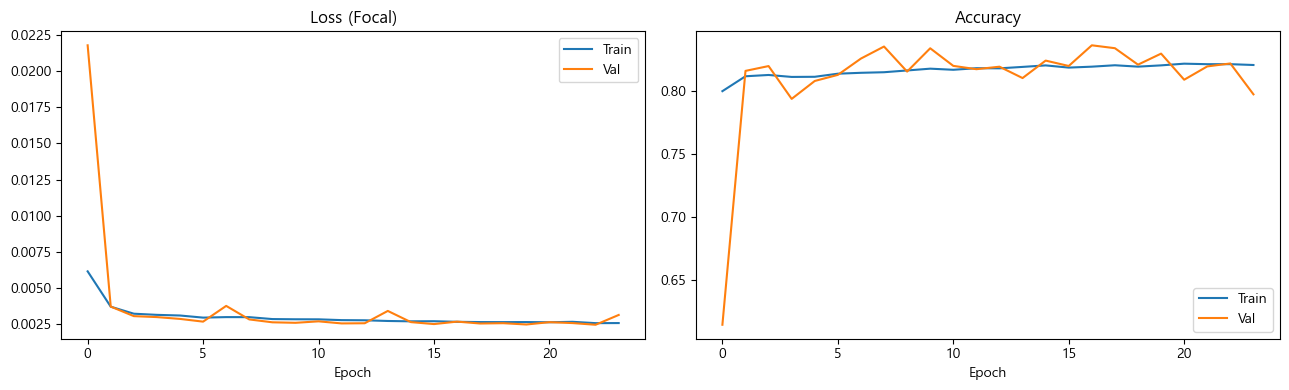

In [17]:
# Loss / Accuracy 커브
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss (Focal)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. 평가

In [18]:
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=== Classification Report (v2 - Focal Loss) ===")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

=== Classification Report (v2 - Focal Loss) ===
               precision    recall  f1-score   support

       Benign     0.9620    0.3523    0.5158     75000
          Bot     0.9993    0.9999    0.9996     42929
  Brute Force     0.8517    0.9504    0.8983     57269
         DDoS     0.9993    0.9979    0.9986     75000
          DoS     0.9594    0.8739    0.9146     75000
 Infiltration     0.3256    0.9513    0.4851     24290
SQL Injection     0.1348    1.0000    0.2375       150

     accuracy                         0.8220    349638
    macro avg     0.7474    0.8751    0.7214    349638
 weighted avg     0.9114    0.8220    0.8247    349638



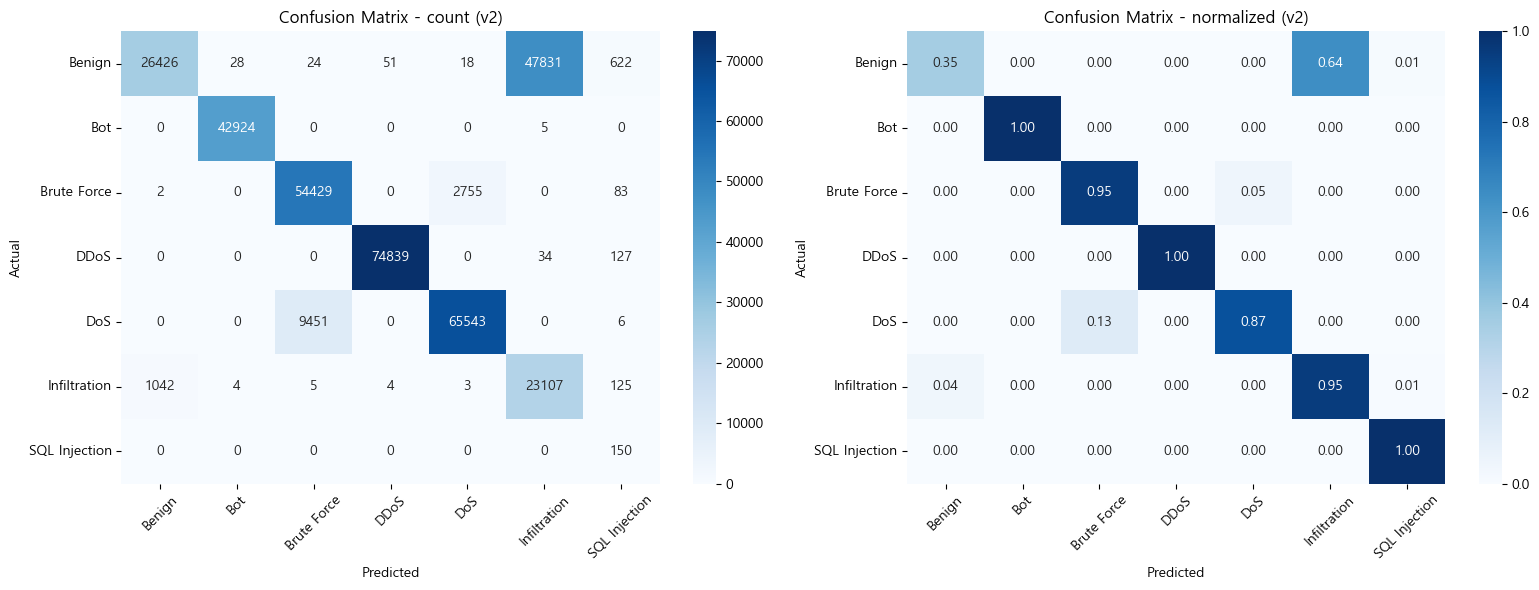

In [19]:
# Confusion Matrix
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix - count (v2)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix - normalized (v2)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 8. 모델 저장

In [20]:
meta = {
    "version"        : "v2",
    "loss"           : "FocalLoss",
    "gamma"          : 2.0,
    "num_features"   : num_features,
    "num_classes"    : num_classes,
    "class_names"    : class_names,
    "label_mapping"  : label_mapping,
    "batch_size"     : BATCH_SIZE,
    "epochs_trained" : len(history["train_loss"]),
    "best_val_loss"  : round(best_val_loss, 6),
}
with open(os.path.join(MODEL_DIR, "model_meta_v2.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("저장 완료!")
print(f"  models/best_model_v2.pt   — v2 가중치")
print(f"  models/model_meta_v2.json — v2 메타데이터")

저장 완료!
  models/best_model_v2.pt   — v2 가중치
  models/model_meta_v2.json — v2 메타데이터
